# Phase 1: Clinical Data Profiling & Structural Audit Pipeline
**Author:** Eliana D
**Context:** Carisurg MedTech Pathways — Week 5  
**Objective:** Execute a formal structural audit on 55,121 Emergency Department (ED) triage records to evaluate predictive feasibility for Emergency Severity Index (ESI) classification.

---
## 1. Data Ingestion & Shape Verification




In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load dataset
df = pd.read_csv("../yaleemmlc_admissionprediction_triage.csv", index_col=0, on_bad_lines='skip')
TARGET = "esi"

# 1. Shape Assessment
rows, cols = df.shape
print(f"=== DATA TELEMETRY ===")
print(f"Total Patient Presentation Records (Rows): {rows:,}")
print(f"Total Collected Features (Columns): {cols}\n")

# 2. Structural Summary
print("=== DATAFRAME INFO SUMMATION ===")
df.info()

# 3. Explicit Data Type (dtype) Audit
print("\n=== COLUMN TYPE INVENTORY ===")
print(df.dtypes.value_counts())

=== DATA TELEMETRY ===
Total Patient Presentation Records (Rows): 55,121
Total Collected Features (Columns): 225

=== DATAFRAME INFO SUMMATION ===
<class 'pandas.core.frame.DataFrame'>
Index: 55121 entries, 7 to 433332
Columns: 225 entries, dep_name to cc_wristpain
dtypes: float64(210), object(15)
memory usage: 95.0+ MB

=== COLUMN TYPE INVENTORY ===
float64    210
object      15
Name: count, dtype: int64


In [32]:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

PLAUSIBLE = {
    "age": (0, 120), "esi": (1, 5), "triage_vital_hr": (20, 250),
    "triage_vital_sbp": (50, 300), "triage_vital_dbp": (20, 200),
    "triage_vital_rr": (4, 60), "triage_vital_o2": (50, 100),
    "triage_vital_temp": (86, 110), "triage_glucose": (20, 800)
}

df_clean = df[df[TARGET].notna()].copy()
for col in VITALS + ["age"]:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
for col, (low, high) in PLAUSIBLE.items():
    if col in df_clean.columns:
        df_clean.loc[(df_clean[col] < low) | (df_clean[col] > high), col] = np.nan

## 2. Missingness Mapping & Missing Data Analysis
The following section profiles the missing data density across the dataset's core structural features (excluding sparse chief complaint binary flags).

In [33]:
# Separate structured metadata features from binary chief complaint indicators
structured_cols = [c for c in df.columns if not c.startswith('cc_') and c != 'o2_missing']

# Build Missingness Metrics Table
missing_counts = df[structured_cols].isna().sum()
missing_pcts = (df[structured_cols].isna().mean() * 100).round(4)

missing_profile = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_pcts
}).sort_values(by='Missing Count', ascending=False)

print("=== COHORT STRUCTURAL MISSINGNESS AUDIT ===")
print(missing_profile.to_string())

=== COHORT STRUCTURAL MISSINGNESS AUDIT ===
                        Missing Count  Missing Percentage (%)
dep_name                            0                     0.0
esi                                 0                     0.0
age                                 0                     0.0
gender                              0                     0.0
ethnicity                           0                     0.0
race                                0                     0.0
lang                                0                     0.0
religion                            0                     0.0
maritalstatus                       0                     0.0
employstatus                        0                     0.0
insurance_status                    0                     0.0
disposition                         0                     0.0
arrivalmode                         0                     0.0
arrivalmonth                        0                     0.0
arrivalday                

In [34]:
# Check if oxygen missingness is related to a patient's true acuity level
df['o2_missing'] = df['triage_vital_o2'].isna()
print(pd.crosstab(df['o2_missing'], df[TARGET], normalize='index') * 100)

esi              1.0        2.0        3.0       4.0       5.0
o2_missing                                                    
False       0.139693  32.517552  49.001288  16.13904  2.202427


## 3. Descriptive Statistical Profile & Outlier Boundary Boundaries
Statistical overview of clinical vectors to determine mathematical dispersion and reveal noise limits prior to filtration bounds.

In [35]:
# Descriptive summary for core numeric features and clinical vitals
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr", "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

# Force check to show statistical metrics across baseline integers
print("=== NUMERIC DISTRIBUTION PROFILES ===")
print(df[['age', TARGET] + VITALS].apply(pd.to_numeric, errors='coerce').describe().T)

=== NUMERIC DISTRIBUTION PROFILES ===
                     count        mean        std   min    25%    50%    75%  \
age                55121.0   55.315470  19.544287  18.0   40.0   55.0   70.0   
esi                55121.0    2.877470   0.751829   1.0    2.0    3.0    3.0   
triage_vital_hr    55121.0   86.447618  16.955556  32.0   74.0   85.0   97.0   
triage_vital_sbp   55121.0  133.680403  22.645812  53.0  118.0  132.0  147.0   
triage_vital_dbp   55121.0   79.531401  14.594082  27.0   70.0   79.0   89.0   
triage_vital_rr    55121.0   17.842073   2.066015   8.0   16.0   18.0   18.0   
triage_vital_o2    55121.0   97.021393   2.084465  62.0   96.0   98.0   98.0   
triage_vital_temp  55121.0   98.090311   0.813266  91.5   97.7   98.0   98.4   
triage_glucose     55121.0  130.086138  73.664073  16.0   93.0  107.0  134.0   

                      max  
age                 107.0  
esi                   5.0  
triage_vital_hr     221.0  
triage_vital_sbp    266.0  
triage_vital_dbp    1

### 4. High-Dimensionality and Signal Sparsity in free-text Chief Complaints
---
Chief complaint (CC) indicators are derived from free-text strings. A high dimension (200 binary columns) paired with extreme sparsity (low prevalence) indicates a weak predictive signal. This sparsity is a primary vulnerability for automated model training. We must identify features with zero to near-zero variance (prevalence <0.5%) that are effectively constant.

In [36]:
# Calculate how many of the 200 chief complaints appear in fewer than 0.5% of patients
cc_cols = [c for c in df.columns if c.startswith('cc_')]

# Convert all chief complaint columns to numeric, forcing stray text strings into NaN
df_cc_numeric = df[cc_cols].apply(pd.to_numeric, errors='coerce')

# Calculate column averages safely, ignoring missing/bad rows
sparse_count = (df_cc_numeric.mean() < 0.005).sum()

print(f"Out of {len(cc_cols)} chief complaints, {sparse_count} columns are highly sparse (<0.5% prevalence).")

Out of 200 chief complaints, 149 columns are highly sparse (<0.5% prevalence).


### 5. Vitals Plausibility & Clinical Correlation Dashboard
---
This visualization suite executes final validations on the cleaned, filtered cohort. By cross-examining inter-feature relationships and known clinical logic, we verify the data integrity before submitting it to modelling.

**Analytical Objectives:**
* **Vital Correlation Matrix:** Measure inter-vital relationships to ensure clinical plausibility. (Vulnerability: Do extreme vital signs accurately correlate, or is there still sensor noise?)
* **Operational Validation:** Assess final target distribution stability across the five ESI acuity categories.
* **Logic Check:** Audit high-risk indicators, ensuring they skew appropriately into higher-urgency tracks as clinically expected.

In [37]:
# Show which vitals correlate best/worst with the target ESI score
print("Vitals Correlation Matrix with ESI:")
print(df_clean[VITALS + [TARGET]].corr()[TARGET])

# Check how chest pain skews urgency levels
print("\nChest Pain Urgency Cross-tabulation:")
print(pd.crosstab(df_clean['cc_chestpain'], df_clean[TARGET], normalize='index') * 100)

Vitals Correlation Matrix with ESI:
triage_vital_hr     -0.095191
triage_vital_sbp     0.001304
triage_vital_dbp     0.046468
triage_vital_rr     -0.097365
triage_vital_o2      0.177859
triage_vital_temp   -0.021820
triage_glucose      -0.078230
esi                  1.000000
Name: esi, dtype: float64

Chest Pain Urgency Cross-tabulation:
esi                1.0        2.0         3.0        4.0       5.0
cc_chestpain                                                      
0.0           0.141996  30.597160   49.671270  17.230111  2.359463
1.0           0.107817  59.137466   39.703504   1.024259  0.026954
2.0           0.000000   0.000000  100.000000   0.000000  0.000000


Rows: 7,430  |  Structured columns: 25

Actual missingness per column:
dep_name                  0
esi                       0
age                       0
gender                    0
ethnicity                 0
race                      0
lang                      0
religion                  0
maritalstatus             1
employstatus              1
insurance_status          1
disposition               1
arrivalmode               1
arrivalmonth              1
arrivalday                1
arrivalhour_bin           1
previousdispo             1
triage_vital_hr           1
triage_vital_sbp          1
triage_vital_dbp          1
triage_vital_rr           1
triage_vital_o2           1
triage_vital_o2_device    1
triage_vital_temp         1
triage_glucose            1


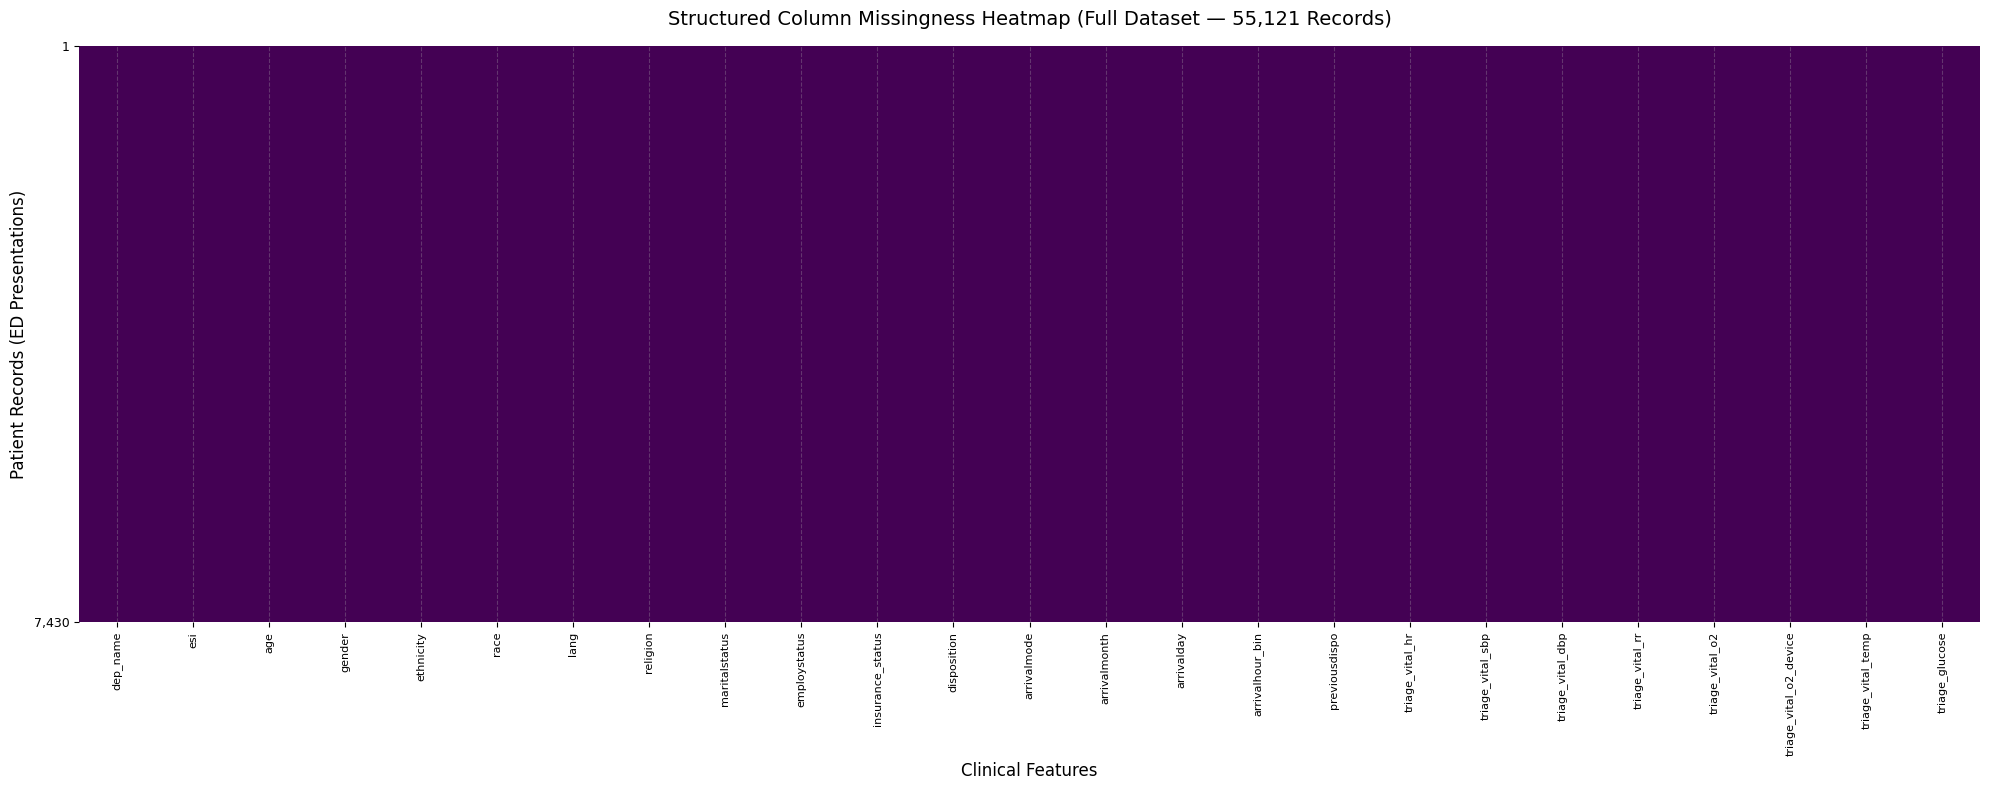

In [ ]:
# Remove any accidentally added columns first
df = df.drop(columns=['o2_missing'], errors='ignore')

# Get all structured columns (no cc_ flags)
structured = [c for c in df.columns if not c.startswith('cc_')]

print(f"Rows: {len(df):,}  |  Structured columns: {len(structured)}")
print("\nActual missingness per column:")
print(df[structured].isna().sum().to_string())


plt.figure(figsize=(20, 8))
sns.heatmap(
    df[structured].isna(),   # .isna() on raw strings returns False — they are NOT missing
    cbar=False,
    cmap="viridis",            # dark = present, white/light = missing
    yticklabels=False,
    xticklabels=True
)

plt.title("Structured Column Missingness Heatmap (Full Dataset — 55,121 Records)",
          fontsize=14, pad=15)
plt.xlabel("Clinical Features", fontsize=12)
plt.ylabel("Patient Records (ED Presentations)", fontsize=12)
plt.xticks(rotation=90, fontsize=8)

# Show row numbers at top and bottom like the example
ax = plt.gca()
ax.set_yticks([0, len(df) - 1])
ax.set_yticklabels(['1', f'{len(df):,}'], fontsize=9)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("../figs/missingness_heatmap.png", bbox_inches='tight', dpi=150)
plt.show()

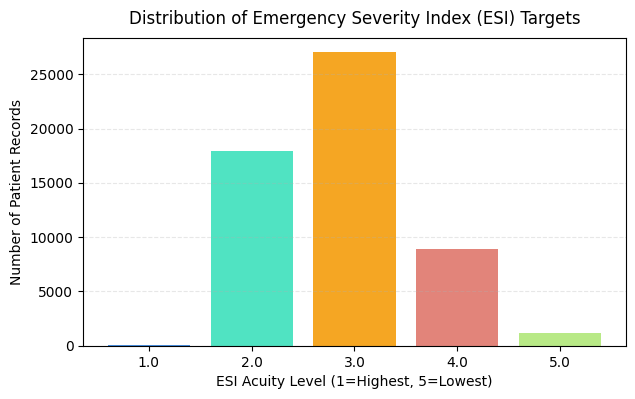

In [38]:
# 2. ESI Distribution Target Chart
plt.figure(figsize=(7, 4))

# Compute counts
esi_counts = df_clean['esi'].value_counts().sort_index()

# Plot directly as a clean bar chart
plt.bar(esi_counts.index.astype(str), esi_counts.values, color=['#4A90E2', '#50E3C2', '#F5A623', '#E2847A', '#B8E986'])

plt.title("Distribution of Emergency Severity Index (ESI) Targets", fontsize=12, pad=10)
plt.xlabel("ESI Acuity Level (1=Highest, 5=Lowest)", fontsize=10)
plt.ylabel("Number of Patient Records", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Save and show
plt.savefig("../figs/esi_distribution.png", bbox_inches='tight', dpi=300)
plt.show()


Dashboard graphics successfully saved to the /figs directory!


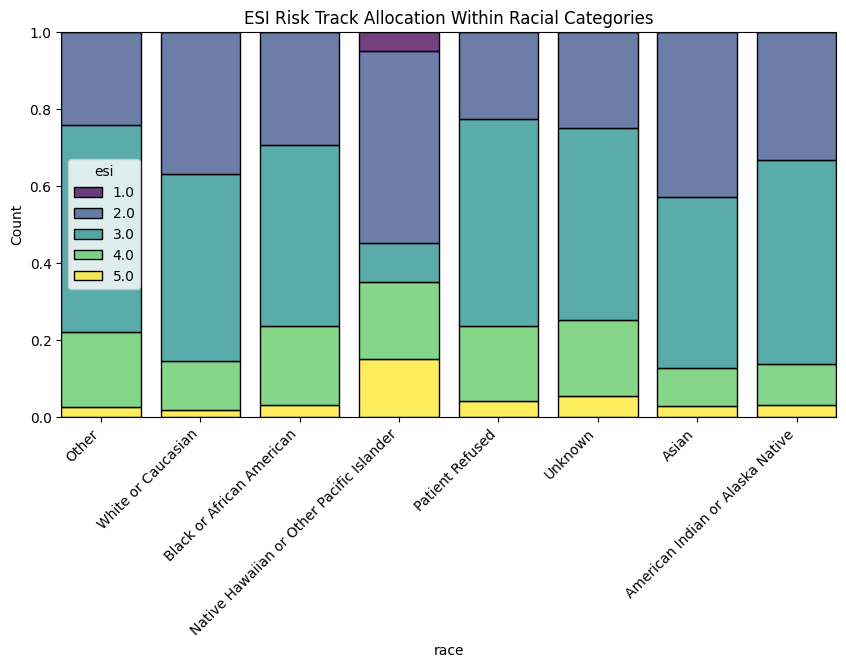

In [39]:
# 3. Clinical Equity Bias Check Plot
plt.figure(figsize=(10, 5))
sns.histplot(data=df_clean, x='race', hue='esi', multiple='fill', shrink=0.8, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title("ESI Risk Track Allocation Within Racial Categories")
plt.savefig("../figs/equity_race_bias.png", bbox_inches='tight')


print("Dashboard graphics successfully saved to the /figs directory!")

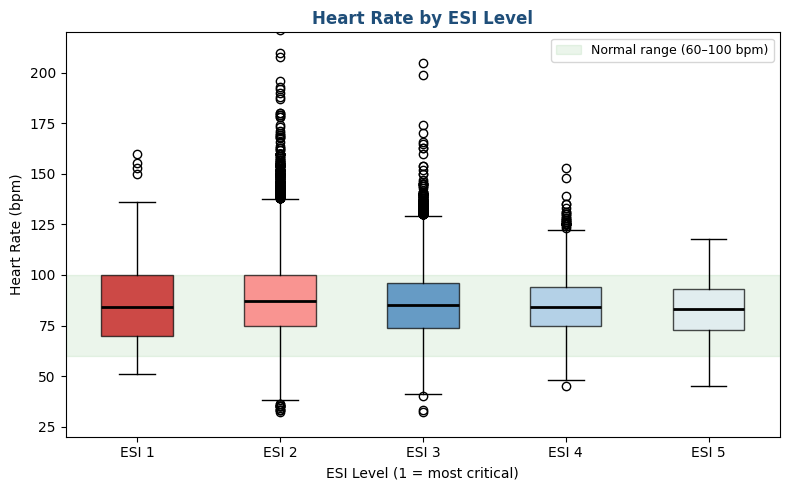

In [40]:
# Group heart rate values by ESI level
esi_levels = sorted(df['esi'].dropna().unique())
groups = [df.loc[df['esi'] == level, 'triage_vital_hr'].dropna() for level in esi_levels]

# Build the boxplot
fig, ax = plt.subplots(figsize=(8, 5))

bp = ax.boxplot(
    groups,
    tick_labels=[f'ESI {int(l)}' for l in esi_levels],
    patch_artist=True,                                    # fills boxes with colour
    medianprops=dict(color='black', linewidth=2)            # red median line
)

# Colour each box by severity — red = most critical, light blue = least
severity_colours = ['#C00000', '#FF6B6B', '#2E75B6', '#9DC3E6', '#DEEAF1']
for patch, colour in zip(bp['boxes'], severity_colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)

ax.set_title('Heart Rate by ESI Level', fontweight='bold', color='#1F4E79', fontsize=12)
ax.set_xlabel('ESI Level (1 = most critical)')
ax.set_ylabel('Heart Rate (bpm)')
ax.set_ylim(20, 220)

# Add normal range shading (60–100 bpm)
ax.axhspan(60, 100, alpha=0.08, color='green', label='Normal range (60–100 bpm)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('heart_rate_by_esi.png', dpi=130, bbox_inches='tight')
plt.show()